In [190]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from tqdm import trange
from sklearn.model_selection import train_test_split
from keras.regularizers import L2

# import  settings
import plot_settings
plot_settings.apply()

In [191]:
# Load data

i = [0.5,0.75,1.0,1.25,1.5,1.75,2.0]
I0 = 0.75
X = np.load(f'data/{I0}_feature.npz')['arr_0'][:, :]
y = np.load(f'data/{I0}_target.npz')['arr_0']
# for i0 in i:
#     X = np.vstack((X,np.load(f'data/{i0}_feature.npz')['arr_0'][:, :]))
#     y = np.vstack((y,np.load(f'data/{i0}_target.npz')['arr_0']))


# X_train = np.ones((100, 3)) * X_train
# print(X_train[:2, :])
# print(y_train)

In [192]:
print(X.shape); print(y.shape)

(1639, 21)
(1639, 20)


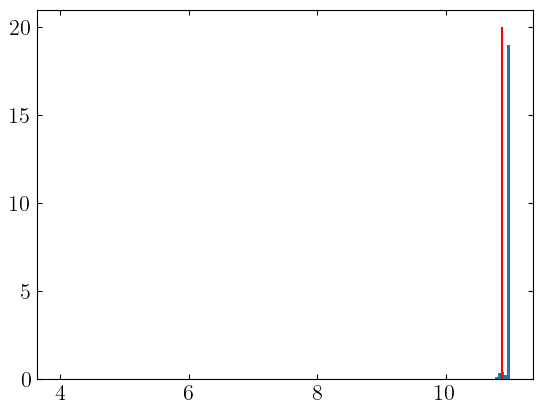

In [193]:
plt.hist(np.mean(y,axis = 1), bins=150,density=True)
plt.vlines([14.50*I0],0,20, color='red', label='k*I')
plt.show()

In [194]:
def normalize(X):
    return (X - X.min()) / (X.max() - X.min())
    #return (X - X.mean()) / X.std()

def denormalize(X_norm, X_orig):
    return X_norm * (X_orig.max() - X_orig.min()) + X_orig.min()
    #return X_norm * X_orig.std() + X_orig.mean()

In [195]:
X_train = X.copy()
X_train[:,1:] = (X[:,1:])
y_train = y.copy()

In [196]:
# # Split data into training, validation, and test sets
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
# X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [197]:
input_shape = X_train.shape
output_shape = y_train.shape
print(input_shape, output_shape)

(1639, 21) (1639, 20)


In [198]:
model = keras.models.Sequential([   
    keras.layers.Input(shape=(input_shape[1],)),
    keras.layers.Dense(128, activation='tanh'),
    keras.layers.Dense(64),
    keras.layers.Dense(64),
    keras.layers.Dense(20, activation='relu'),
])

In [199]:
# model = keras.models.Sequential([     
#     keras.layers.Bidirectional(keras.layers.LSTM(64,recurrent_regularizer=L2(0.01),return_sequences=True),input_shape=(input_shape[1],1)),
#     keras.layers.LSTM(32,return_sequences=False),
#     keras.layers.Dense(units=64, activation='relu'),
#     keras.layers.Dense(units=64, activation='relu'),
#     keras.layers.Dense(units=64, activation='relu'),
#     keras.layers.Dense(20, activation='relu'),
# ])

On custom-made loss functions: [link](https://medium.com/@Bloomore/how-to-write-a-custom-loss-function-with-additional-arguments-in-keras-5f193929f7a0)


In [ ]:
# def custom_loss(y_true, y_pred):
#   MSE_u = keras.losses.mean_squared_error(y_true, y_pred)



#   return MSE_u + MSE_f

In [ ]:
# def my_loss(y_true,y_pred):

#     with tf.GradientTape() as tape:
#         y_pred = model(X)
#         mse = ...
#         phys = ...
#         loss = mse + phys
#     return mse + lam * phy

In [ ]:
# def my_loss(I= I0,k = 14.5):
#     def loss(y_true, y_pred):
#         MSE_phys = (tf.reduce_mean(y_pred,axis = 1) - k * I)**2
#         MSE_data = tf.reduce_mean(tf.abs(y_true - y_pred))
#         return MSE_data
#     return loss

In [ ]:
model.compile(
  optimizer='adam',
  loss='mse',metrics=['accuracy'])

In [189]:
epochs = 100  ## Number of epoch to run
batch_size = 32  ## Number of samples per gradient update

#es = keras.callbacks.EarlyStopping('val_loss', patience=10, restore_best_weights = True)
# Train the model
history = model.fit(
  X_train, y_train,
  epochs=epochs,
  verbose = 1,
  )

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0439 - loss: 1.7949     
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0372 - loss: 1.7936
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1135 - loss: 1.7947     
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0915 - loss: 1.7979     
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1245 - loss: 1.7942   
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step - accuracy: 0.0085 - loss: 1.7975   
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 809us/step - accuracy: 0.0988 - loss: 1.7990   
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.0964 - loss: 1.7969
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - accuracy: 0.1354 - loss: 1.7988   
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - accuracy: 0.0354 - loss: 1.7941   
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step - accuracy: 0.0555 - loss: 1.7969   
Epoch 12/100
52/52

Text(0, 0.5, 'Loss')

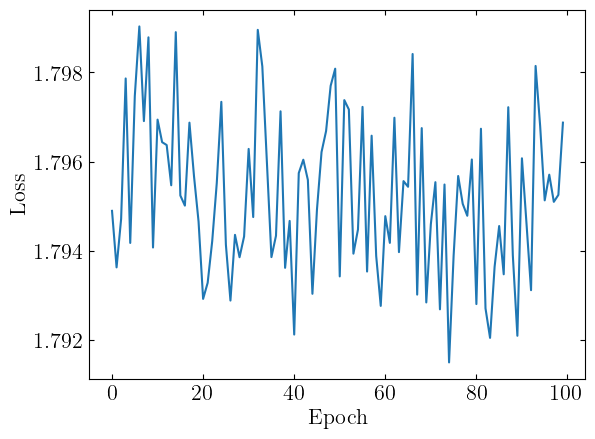

In [202]:
train_loss = history.history['loss']
# val_loss = history.history['val_loss']

plt.plot(train_loss, label='Training loss')
# plt.plot(val_loss, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [203]:
X_unseen = (np.load(f'data/0.76_feature.npz')['arr_0'])
y_unseen = (np.load(f'data/0.76_target.npz')['arr_0'])

In [154]:
y_preds = np.zeros_like(y_unseen)
mse = np.zeros(len(X_unseen))

for c in range(len(X_unseen)):
    if c == 0:
        X_test = X_unseen[0,:]
    else:
        X_test[0] = X_unseen[c,0]
        X_test[1:] = y_pred
    y_pred = model.predict(X_test.reshape(1,-1),verbose=0)
    y_preds[c] = y_pred.flatten()
    mse[c] = np.mean((y_pred.flatten() - y_unseen[c])**2)
    if c % 50 == 0:
        print(f"t: {c} \t Difference: {mse[c]}")

t: 0 	 Difference: 166.76551753947805
t: 50 	 Difference: 31.45576782664939
t: 100 	 Difference: 46.12608170518622
t: 150 	 Difference: 46.74036692891802
t: 200 	 Difference: 47.78382235000816
t: 250 	 Difference: 48.15281396684387
t: 300 	 Difference: 47.837708155726226
t: 350 	 Difference: 47.824692476685925
t: 400 	 Difference: 47.76433202193939
t: 450 	 Difference: 47.7871903212334
t: 500 	 Difference: 47.784389727530574
t: 550 	 Difference: 47.78899378003774
t: 600 	 Difference: 47.78756462457456
t: 650 	 Difference: 47.78819601413708
t: 700 	 Difference: 47.78836912590286
t: 750 	 Difference: 47.78808234803724
t: 800 	 Difference: 47.78823387992853
t: 850 	 Difference: 47.788386819682955
t: 900 	 Difference: 47.788496051985895
t: 950 	 Difference: 47.788561785143074
t: 1000 	 Difference: 47.78856744241557
t: 1050 	 Difference: 47.78853606629205
t: 1100 	 Difference: 47.78845424948218
t: 1150 	 Difference: 47.78844545781284
t: 1200 	 Difference: 47.78845763471104
t: 1250 	 Differe

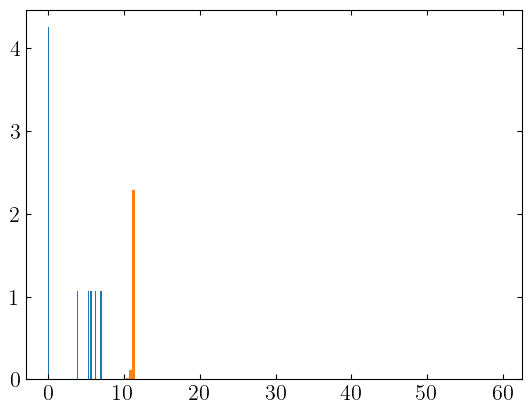

In [155]:
plt.hist(y_preds.flatten(), bins=150,density=True)
plt.hist(y_unseen.flatten(), bins=150,density=True)
plt.show()

Text(0, 0.5, 'MSE')

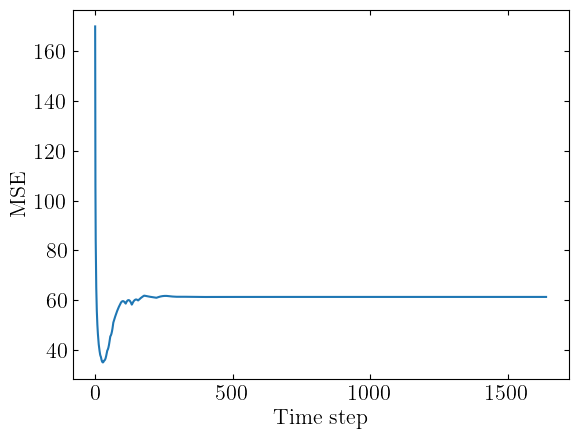

In [ ]:
plt.plot(np.linspace(0,len(y_unseen),len(y_unseen)),mse, label='MSE per time step')
plt.xlabel('Time step')
plt.ylabel('MSE')

Text(0, 0.5, 'Mean value')

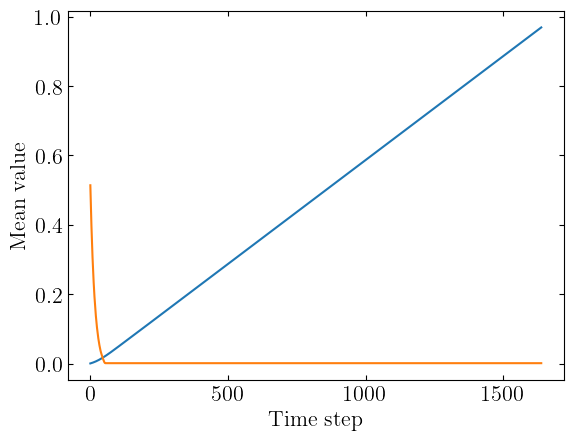

In [ ]:
yp_mean = np.mean(y_preds, axis=1)
y_mean = np.mean(y_unseen, axis=1)

plt.plot(y_mean, label='True mean')
plt.plot(yp_mean, label='Predicted mean')
plt.xlabel('Time step')
plt.ylabel('Mean value')

15
(15, 1639) (15, 1639) (1639, 15)


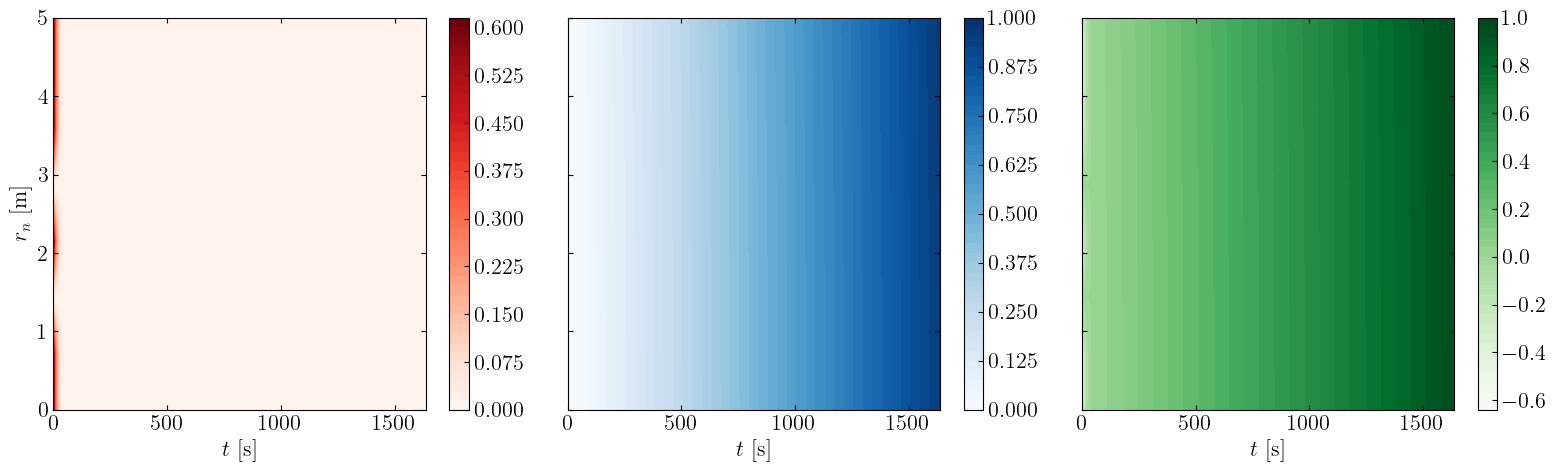

In [ ]:
cut = 5

y_preds_denorm = y_preds[:,:-cut]#, np.load(f'data/0.245_target.npz')['arr_0'][:,:-cut]
y_unseen_denorm =y_unseen[:,:-cut]#, np.load(f'data/0.245_target.npz')['arr_0'][:,:-cut]

print(y_unseen_denorm.shape[1])
t = np.arange(len(y_unseen_denorm))
r = np.linspace(0,10, y_unseen_denorm.shape[1])




T,R = np.meshgrid(t,r)

print(R.shape,T.shape,y_unseen_denorm.shape)
fig ,ax = plt.subplots(1,3, figsize=(16,5),sharey=True)

y_preds_denorm = y_preds_denorm.T
y_unseen_denorm = y_unseen_denorm.T

cs = ax[0].contourf(T, R, y_preds_denorm, levels=40, cmap="Reds")
fig.colorbar(cs, ax=ax[0])
ax[0].set_xlabel("$t$ [s]")

cs = ax[1].contourf(T, R, y_unseen_denorm, levels=40, cmap="Blues")
fig.colorbar(cs, ax=ax[1])
ax[1].set_xlabel("$t$ [s]")
ax[0].set_ylabel("$r_n$ [m]")

cs = ax[2].contourf(T, R, -y_preds_denorm + y_unseen_denorm, levels=40, cmap="Greens")
ax[2].set_xlabel("$t$ [s]")

fig.colorbar(cs, ax=ax[2])

ax[0].set_ylim(0, 5)
plt.tight_layout()
